In [1]:
### Module 2.3: Cartographie du carbone des sols

## 2.3.1 Installer et importer les bibliothèques
#⏳L’installation des paquets requis peut prendre 1 à 2 minutes, selon la vitesse de votre connexion internet.
#_________________________________________________________

# Installer le module matplotlib_scalebar 

!python -m pip install matplotlib_scalebar

 

# Installer les bibliothèques pour le traitement et la visualisation de données géospatiales

!pip install rioxarray numpy matplotlib xarray

 

# Installer les bibliothèques pour le traitement des données raster et vectorielles

!pip install rasterio geopandas

 

# Importer les bibliothèques nécessaires à l’analyse géospatiale, au traitement de données et à la visualisation

import os

import datacube

import pickle

import math

import numpy as np

import geopandas as gpd

import pandas as pd

import xarray as xr

import matplotlib.colors as mcolors

import matplotlib.pyplot as plt

from IPython.display import Image

from odc.geo.geom import Geometry

from datacube.utils.cog import write_cog

from deafrica_tools.plotting import plot_lulc, xr_animation

from deafrica_tools.spatial import xr_rasterize

from deafrica_tools.areaofinterest import define_area

from matplotlib_scalebar.scalebar import ScaleBar

import matplotlib.pyplot as plt

import matplotlib.patches as mpatches

import rasterio as rio

from pyproj import Transformer

from urllib.parse import urlparse

import boto3

from pystac import stac_io, Catalog

from deafrica_tools.plotting import display_map, rgb

from deafrica_tools.load_isda import load_isda

#_________________________________________________________

#Ces bibliothèques permettent de gérer l’entrée/sortie géospatiale (rioxarray, rasterio), d’accéder aux données d’observation de la Terre (datacube, pystac, boto3), de traiter les données vectorielles (geopandas) et de créer des visualisations efficaces (scalebar, patches). La fonction essentielle load_isda permet de charger les couches de carbone du sol fournies par ISDA. Veillez à utiliser les mêmes versions de bibliothèques pour garantir la reproductibilité de vos analyses.

In [2]:
## 2.3.2 Définir la zone d’intérêt (AOI) à partir d’un fichier GeoJSON
#Chargez le polygone représentant votre zone d’étude (ex.: Sidi Bouzid) afin que les données soient automatiquement découpées selon ses contours.
#______________________________________________________________

# Utiliser un polygone depuis un fichier GeoJSON ou un shapefile Esri 

aoi = define_area(vector_path='PONASI_prov_merg.geojson')

 

# Créer un polygone géospatial et un GeoDataFrame pour la zone d’intérêt

geopolygon = Geometry(aoi["features"][0]["geometry"], crs="epsg:4326")

geopolygon_gdf = gpd.GeoDataFrame(geometry=[geopolygon], crs=geopolygon.crs)

 

# Extraire les coordonnées de latitude et de longitude du polygone

lat_range = (geopolygon_gdf.total_bounds[1], geopolygon_gdf.total_bounds[3])

lon_range = (geopolygon_gdf.total_bounds[0], geopolygon_gdf.total_bounds[2])

#______________________________________________________________

#Interprétation: Définir la zone d’étude via un fichier GeoJSON ou Shapefile permet de cibler précisément les données de carbone du sol, en évitant les chargements de données inutiles.


In [3]:
## 2.3.3 Charger les données de carbone du sol et les masquer à la zone d’intérêt (AOI)
#Cette étape consiste à récupérer les couches du produit ISDA (moyennes et écarts-types aux profondeurs 0–20 cm et 20–50 cm), à les masquer selon la zone d’étude, puis à estimer le stock de carbone sur 0–30 cm de profondeur.

#Initialiser l’instance Datacube
#______________________________________________________________

dc = datacube.Datacube(app='iSDA-soil')

 

# Lister et filtrer les produits disponibles

dc_products = dc.list_products()

display_columns = ['name', 'description']

dc_products[dc_products.name.str.contains('soil').fillna(False)][display_columns].set_index('name')

#______________________________________________________________

,description
name,
isda_soil_bedrock_depth,Soil bedrock depth predictions made by iSDA Af...
isda_soil_bulk_density,Soil bulk density predictions made by iSDA Africa
isda_soil_carbon_total,Soil total carbon predictions made by iSDA Africa
isda_soil_clay_content,Soil clay content predictions made by iSDA Africa
isda_soil_sand_content,Soil sand content predictions made by iSDA Africa
isda_soil_silt_content,Soil silt content predictions made by iSDA Africa
wapor_soil_moisture,WaPOR v3 Level 2 100m dekadal relative root zo...


In [4]:
#Récupérer les mesures du produit ('isda_soil_carbon_total'):
#______________________________________________________________

product_name = 'isda_soil_carbon_total'

 

dc_measurements = dc.list_measurements()

dc_measurements.loc[product_name].drop('flags_definition', axis=1)
#______________________________________________________________

,name,dtype,units,nodata,aliases,add_offset,scale_factor
measurement,,,,,,,
mean_0_20,mean_0_20,float32,g/kg,NaN,[MEAN_0_20],NaN,NaN
mean_20_50,mean_20_50,float32,g/kg,NaN,[MEAN_20_50],NaN,NaN
stdev_0_20,stdev_0_20,float32,g/kg,NaN,[STDEV_0_20],NaN,NaN
stdev_20_50,stdev_20_50,float32,g/kg,NaN,[STDEV_20_50],NaN,NaN


In [5]:
#______________________________________________________________

ds = dc.load(product="isda_soil_carbon_total",

             measurements=['mean_0_20', 'mean_20_50', 'stdev_0_20', 'stdev_20_50'],

             x = lon_range,

             y = lat_range,

             output_crs="EPSG:6933",

             resolution=(30, 30)

             )


print(ds)
#______________________________________________________________

<xarray.Dataset> Size: 811MB
Dimensions:      (time: 1, y: 5583, x: 9078)
Coordinates:
  * time         (time) datetime64[ns] 8B 2009-01-01
  * y            (y) float64 45kB 1.382e+06 1.382e+06 ... 1.549e+06 1.549e+06
  * x            (x) float64 73kB -2.709e+05 -2.709e+05 ... 1.395e+03 1.425e+03
    spatial_ref  int32 4B 6933
Data variables:
    mean_0_20    (time, y, x) float32 203MB 28.0 27.0 27.0 ... 19.0 19.0 19.0
    mean_20_50   (time, y, x) float32 203MB 26.0 26.0 26.0 ... 18.0 18.0 18.0
    stdev_0_20   (time, y, x) float32 203MB 3.0 3.0 3.0 3.0 ... 3.0 3.0 4.0 4.0
    stdev_20_50  (time, y, x) float32 203MB 2.0 2.0 2.0 2.0 ... 2.0 2.0 3.0 3.0
Attributes:
    crs:           EPSG:6933
    grid_mapping:  spatial_ref


In [6]:
#Masquer le jeu de données avec le polygone du pays
#______________________________________________________________

mask = xr_rasterize(geopolygon_gdf, ds)

ds = ds.where(mask)

#______________________________________________________________

#Visualiser les quatre bandes ISDA côte à côte pour examiner la répartition du carbone dans la couche superficielle (topsoil) et la couche profonde (subsoil) du sol.

In [7]:
#Vérifier les définitions flags de la couche 'mean_0_20'
#______________________________________________________________

# ds_20 = ds.mean_0_20.flags_definition  

# Transformer les données : appliquer l'inverse du log1p (expm1) puis diviser par 10 pour remettre à l’échelle

ds = np.expm1(ds / 10)

#______________________________________________________________

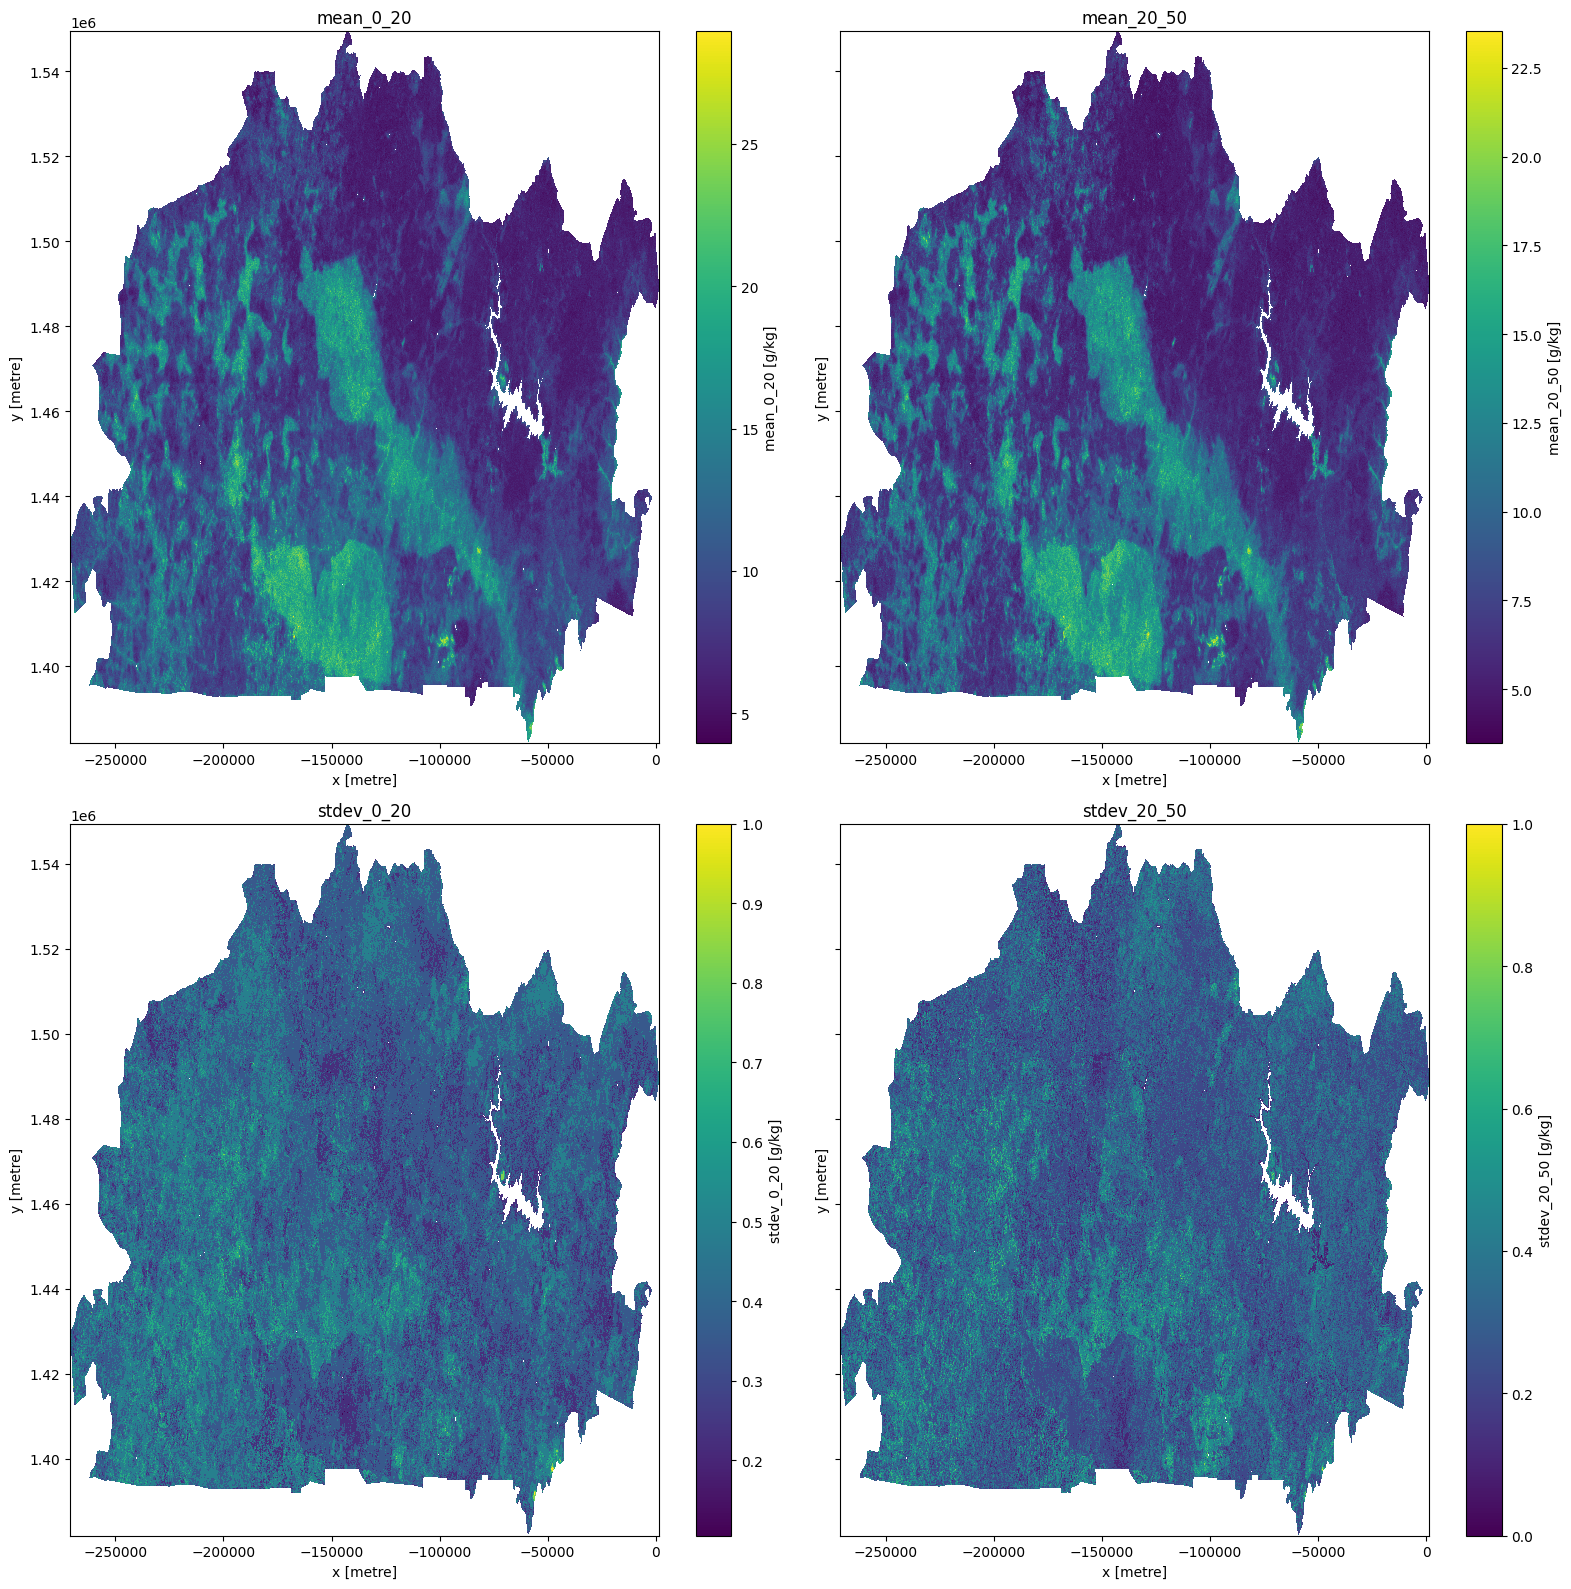

In [8]:
#Afficher les variables du jeu de données dans une grille 2x2
#______________________________________________________________

fig, ax = plt.subplots(2, 2, figsize=(16, 16), sharey=True)

ds[list(ds.keys())[0]].plot(ax=ax[0, 0])

ds[list(ds.keys())[1]].plot(ax=ax[0, 1])

ds[list(ds.keys())[2]].clip(0,1).plot(ax=ax[1, 0])

ds[list(ds.keys())[3]].clip(0,1).plot(ax=ax[1, 1])

ax[0, 0].set_title(list(ds.keys())[0])

ax[0, 1].set_title(list(ds.keys())[1])

ax[1, 0].set_title(list(ds.keys())[2])

ax[1, 1].set_title(list(ds.keys())[3])

plt.tight_layout()

#______________________________________________________________
#Figure 2.3.2 –  Variables du jeu de données affichées dans une grille 2×2

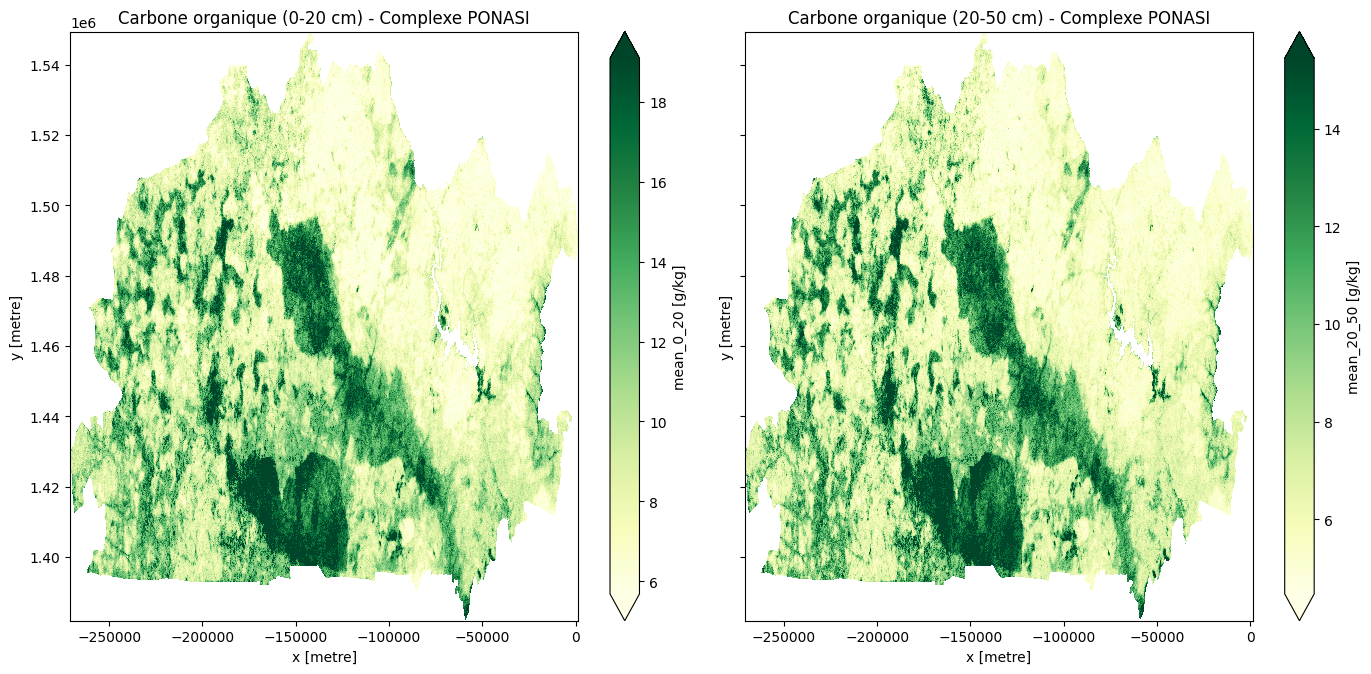

In [9]:
#Visualiser le carbone organique du sol (0–20 cm et 20–50 cm) pour le Complexe PONASIsur deux cartes côte à côte
#______________________________________________________________

fig, ax = plt.subplots(1, 2, figsize=(14, 7), sharey=True)

 

ds.mean_0_20.plot(ax=ax[0], cmap='YlGn', robust=True)

ax[0].set_title("Carbone organique (0-20 cm) - Complexe PONASI")

 

ds.mean_20_50.plot(ax=ax[1], cmap='YlGn', robust=True)

ax[1].set_title("Carbone organique (20-50 cm) - Complexe PONASI")

 

# pour chaque axe (subplot):

#     a.set_aspect('equal')

#     country_shape = gpd.GeoSeries([country_feature["geometry"]], crs="EPSG:4326")

#     country_shape.boundary.plot(ax=a, color="black", linewidth=1.5)

 

plt.tight_layout()

plt.show()

#______________________________________________________________

#Figure 2.3.3 – Couches de carbone du sol masquées (0–20 cm et 20–50 cm)

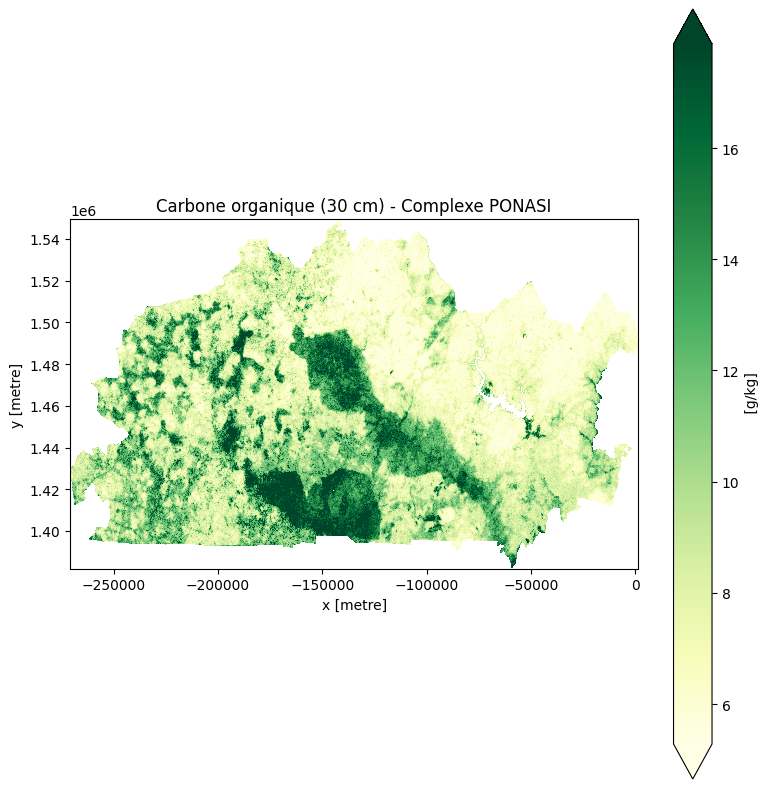

In [10]:
#Combiner les deux bandes de profondeur pour estimer le carbone organique dans la couche biologique active 0–30 cm.

#Calculer et afficher le carbone organique du sol à 30 cm de profondeur pour la Tunisie en utilisant une interpolation pondérée.
#______________________________________________________________

depth_30 = (ds.mean_20_50 * (30 - 20) + ds.mean_0_20 * (50 - 30)) / (50 - 20)

 

fig, ax = plt.subplots(1, 1, figsize=(8, 8))




depth_30.plot(ax=ax, cmap='YlGn', robust=True)

ax.set_title("Carbone organique (30 cm) - Complexe PONASI")

 

ax.set_aspect('equal')

plt.tight_layout()

plt.show()

#______________________________________________________________

#Figure 2.3.4 – Carbone organique du sol pondéré en profondeur (0–30 cm)

In [11]:
#Définir les paramètres pour l’analyse des données
#Agréger à une grille d’occupation du sol plus grossière et/ou interpoler sur une grille personnalisée pour assurer une intégration homogène.
#______________________________________________________________

measurements = "classification"

time_range = ("2014", "2023")

 

initial_year = "2014"

target_year = "2023"

resolution = (-300, 300)

output_crs = "EPSG:6933"

 

output_dir = "results"

os.makedirs(output_dir, exist_ok=True)

#______________________________________________________________

In [12]:
#Charger les données, puis appliquer le masque
#______________________________________________________________

query = {

         "time": time_range,

         "measurements": measurements,

         "resolution": resolution,

         "output_crs": output_crs,

          "x" : lon_range,

           "y" : lat_range

}

ds_lulc = dc.load(product="cci_landcover", **query)

ds_lulc = ds_lulc.where(ds_lulc != 0)

 

ds_lulc

#______________________________________________________________



<xarray.Dataset> Size: 18MB
Dimensions:         (time: 9, y: 559, x: 908)
Coordinates:
  * time            (time) datetime64[ns] 72B 2014-07-02T11:59:59.500000 ... ...
  * y               (y) float64 4kB 1.549e+06 1.549e+06 ... 1.382e+06 1.382e+06
  * x               (x) float64 7kB -2.708e+05 -2.704e+05 ... 1.05e+03 1.35e+03
    spatial_ref     int32 4B 6933
Data variables:
    classification  (time, y, x) float32 18MB 10.0 10.0 120.0 ... 10.0 10.0 10.0
Attributes:
    crs:           EPSG:6933
    grid_mapping:  spatial_ref

In [13]:
#Masquer le jeu de données avec le polygone du Complexe.
#______________________________________________________________

mask = xr_rasterize(geopolygon_gdf, ds_lulc)

ds_lulc = ds_lulc.where(mask)

 

text_font_dict = {

    "no data": "#000000",

    "cropland, rainfed": "#ffff00",

    "cropland, rainfed, herbaceous cover": "#ffff00",

    "cropland, rainfed, tree or shrub cover": "#ffff00",

    "cropland, irrigated or post-flooding": "#ffff00",

    "mosaic cropland/natural vegetation": "#ffff00",

    "mosaic natural vegetation/cropland": "#ffff00",

    "tree cover, broadleaved, evergreen, closed to open": "#054907",

    "tree cover, broadleaved, deciduous, closed to open": "#054907",

    "tree cover, broadleaved, deciduous, closed": "#054907",

    "tree cover, broadleaved, deciduous, open": "#054907",

    "tree cover, needleleaved, evergreen, closed to open": "#054907",

    "tree cover, needleleaved, evergreen, closed": "#054907",

    "tree cover, needleleaved, evergreen, open": "#054907",

    "tree cover, needleleaved, deciduous, closed to open": "#054907",

    "tree cover, needleleaved, deciduous, closed": "#054907",

    "tree cover, needleleaved, deciduous, open": "#054907",

    "tree cover, mixed leaf type": "#054907",

    "mosaic tree and shrub/herbaceous cover": "#054907",

    "mosaic herbaceous cover/tree and shrub": "#ffa500",

    "shrubland": "#ffa500",

    "shrubland, evergreen": "#ffa500",

    "shrubland, deciduous": "#ffa500",

    "grassland": "#ffa500",

    "lichens and mosses": "#ffa500",

    "sparse vegetation": "#ffa500",

    "sparse tree": "#ffa500",

    "sparse shrub": "#ffa500",

    "sparse herbaceous cover": "#ffa500",

    "tree cover, flooded, fresh or brakish water": "#af51ed",

    "tree cover, flooded, saline water": "#af51ed",

    "shrub or herbaceous cover, flooded, fresh/saline/brakish water": "#af51ed",

    "urban areas": "#dc143c",

    "bare areas": "#d6d4b6",

    "consolidated bare areas": "#d6d4b6",

    "unconsolidated bare areas": "#d6d4b6",

    "water bodies": "#069af3",

    "permanent snow and ice": "#d6d4b6",

}

 

country = "Complexe PONASI"

# Extraire les données classées 

ds_cci = ds_lulc["classification"]

 

for i in range(len(ds_cci.time)):

 

    singleTimestamp = ds_cci.isel(time=i)

    year = singleTimestamp.time.dt.strftime('%Y').data

 

    fname = f"{output_dir}/{year}_{country.replace(' ', '')}_ipcc_lulc.tif"

    print(f'Écrire {fname}')


    write_cog(singleTimestamp, fname=fname, overwrite=True)
#______________________________________________________________



Écrire results/2014_ComplexePONASI_ipcc_lulc.tif
Écrire results/2015_ComplexePONASI_ipcc_lulc.tif
Écrire results/2016_ComplexePONASI_ipcc_lulc.tif
Écrire results/2017_ComplexePONASI_ipcc_lulc.tif


/tmp/ipykernel_2484/4111921087.py:115: ODC2DeprecationWarning: Call to deprecated function (or staticmethod) write_cog. (This method has been moved to odc-geo.)
-- Deprecated since version 1.9.0.
  write_cog(singleTimestamp, fname=fname, overwrite=True)
/tmp/ipykernel_2484/4111921087.py:115: ODC2DeprecationWarning: Call to deprecated function (or staticmethod) write_cog. (This method has been moved to odc-geo.)
-- Deprecated since version 1.9.0.
  write_cog(singleTimestamp, fname=fname, overwrite=True)
/tmp/ipykernel_2484/4111921087.py:115: ODC2DeprecationWarning: Call to deprecated function (or staticmethod) write_cog. (This method has been moved to odc-geo.)
-- Deprecated since version 1.9.0.
  write_cog(singleTimestamp, fname=fname, overwrite=True)
/tmp/ipykernel_2484/4111921087.py:115: ODC2DeprecationWarning: Call to deprecated function (or staticmethod) write_cog. (This method has been moved to odc-geo.)
-- Deprecated since version 1.9.0.
  write_cog(singleTimestamp, fname=fname, 

Écrire results/2018_ComplexePONASI_ipcc_lulc.tif
Écrire results/2019_ComplexePONASI_ipcc_lulc.tif
Écrire results/2020_ComplexePONASI_ipcc_lulc.tif
Écrire results/2021_ComplexePONASI_ipcc_lulc.tif


/tmp/ipykernel_2484/4111921087.py:115: ODC2DeprecationWarning: Call to deprecated function (or staticmethod) write_cog. (This method has been moved to odc-geo.)
-- Deprecated since version 1.9.0.
  write_cog(singleTimestamp, fname=fname, overwrite=True)
/tmp/ipykernel_2484/4111921087.py:115: ODC2DeprecationWarning: Call to deprecated function (or staticmethod) write_cog. (This method has been moved to odc-geo.)
-- Deprecated since version 1.9.0.
  write_cog(singleTimestamp, fname=fname, overwrite=True)
/tmp/ipykernel_2484/4111921087.py:115: ODC2DeprecationWarning: Call to deprecated function (or staticmethod) write_cog. (This method has been moved to odc-geo.)
-- Deprecated since version 1.9.0.
  write_cog(singleTimestamp, fname=fname, overwrite=True)
/tmp/ipykernel_2484/4111921087.py:115: ODC2DeprecationWarning: Call to deprecated function (or staticmethod) write_cog. (This method has been moved to odc-geo.)
-- Deprecated since version 1.9.0.
  write_cog(singleTimestamp, fname=fname, 

Écrire results/2022_ComplexePONASI_ipcc_lulc.tif


/tmp/ipykernel_2484/4111921087.py:115: ODC2DeprecationWarning: Call to deprecated function (or staticmethod) write_cog. (This method has been moved to odc-geo.)
-- Deprecated since version 1.9.0.
  write_cog(singleTimestamp, fname=fname, overwrite=True)


In [14]:
#Reclasser le jeu de données et appliquer un masque au résultat.
#______________________________________________________________

#lulc_labels = ["Forest", "Grassland", "Cropland", "Wetland", "Artificial area", "Bare land", "Water"]

# Classes ESA adaptées
#lulc_classes = [1, 2, 3, 4, 5, 6, 7]
lulc_labels = [
    "Forêt claire",
    "Savane arborée/arbustive",
    "Savane herbeuse",
    "Culture annuelle",
    "Parc agroforestier",
    "Zones humides / Forêt galerie",
    "Sol nu & habitat",
    "Eau"
]

lulc_classes = [1,2,3,4,5,6,7,8]
 

#lulc_colors = ["#054907", "#ffa500", "#ffff00", "#af51ed", "#dc143c", "#d6d4b6", "#069af3"]

lulc_colors = [
    "#006400",  # forêt
    "#228B22",  # savane arborée
    "#7CFC00",  # savane herbeuse
    "#FFFF00",  # culture
    "#FFA500",  # parc agroforestier
    "#00CED1",  # zone humide
    "#D2B48C",  # sol nu
    "#0000FF"   # eau
]


#forest_classes = [50, 60, 61, 62, 70, 71, 72, 80, 81, 82, 90, 100]

#grassland_classes = [110, 120, 121, 122, 130, 140, 150, 151, 152, 153]

#cropland_classes = [10, 11, 12, 20, 30, 40]

#wetland_classes = [160, 170, 180]

#artificial_classes = [190]

#bare_land_classes = [200, 201, 202, 220]

#water_classes = [210]


forest_classes = [50,60,61,62,70,71,72,80,81,82,90,100]

savanna_wooded_classes = [120,121,122,140,150,151,152,153]

savanna_grass_classes = [110,130]

cropland_classes = [10,11,12]

agroforest_classes = [20,30,40]

wetland_classes = [160,170,180]

bare_urban_classes = [190,200,201,202,220]

water_classes = [210]



#reclassification_condition = [

   # ds_cci.isin(forest_classes),

   # ds_cci.isin(grassland_classes),

    #ds_cci.isin(cropland_classes),

  #  ds_cci.isin(wetland_classes),

   # ds_cci.isin(artificial_classes),

   # ds_cci.isin(bare_land_classes),

   # ds_cci.isin(water_classes)

#]

reclassification_condition = [
    ds_cci.isin(forest_classes),
    ds_cci.isin(savanna_wooded_classes),
    ds_cci.isin(savanna_grass_classes),
    ds_cci.isin(cropland_classes),
    ds_cci.isin(agroforest_classes),
    ds_cci.isin(wetland_classes),
    ds_cci.isin(bare_urban_classes),
    ds_cci.isin(water_classes)
]


ds_lulc_df = xr.DataArray(

    data=np.select(reclassification_condition, lulc_classes, default=np.nan),

    coords={"time": ds_cci.time, "y": ds_cci.y, "x": ds_cci.x},

    dims=["time", "y", "x"]

).astype(ds_cci.dtype)

 

ds_lulc_df = ds_lulc_df.where(mask)


print(ds_lulc_df)
#______________________________________________________________

#Limite importante (à mentionner dans ton rapport)

#👉 Tu dois absolument préciser :

#Certaines classes telles que les vergers et les parcs agroforestiers sont difficilement distinguables dans les données ESA CCI en raison de la résolution spatiale et de la nature mosaïque des paysages agricoles sahéliens.

<xarray.DataArray (time: 9, y: 559, x: 908)> Size: 18MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, n

In [15]:
#Itérer les données reclassées d’occupation du sol / couverture terrestre
#______________________________________________________________

for i in range(len(ds_lulc_df.time)):

 

    singleTimestamp = ds_lulc_df.isel(time=i)

    year = singleTimestamp.time.dt.strftime('%Y').data

 

    fname = f"{output_dir}/{year}_{country.replace(' ', '')}_reclassified_lulc.tif"

    print(f'Écrire {fname}')


    write_cog(singleTimestamp, fname=fname, overwrite=True)
#______________________________________________________________

Écrire results/2014_ComplexePONASI_reclassified_lulc.tif


/tmp/ipykernel_2484/2744188798.py:19: ODC2DeprecationWarning: Call to deprecated function (or staticmethod) write_cog. (This method has been moved to odc-geo.)
-- Deprecated since version 1.9.0.
  write_cog(singleTimestamp, fname=fname, overwrite=True)


Écrire results/2015_ComplexePONASI_reclassified_lulc.tif
Écrire results/2016_ComplexePONASI_reclassified_lulc.tif
Écrire results/2017_ComplexePONASI_reclassified_lulc.tif


/tmp/ipykernel_2484/2744188798.py:19: ODC2DeprecationWarning: Call to deprecated function (or staticmethod) write_cog. (This method has been moved to odc-geo.)
-- Deprecated since version 1.9.0.
  write_cog(singleTimestamp, fname=fname, overwrite=True)
/tmp/ipykernel_2484/2744188798.py:19: ODC2DeprecationWarning: Call to deprecated function (or staticmethod) write_cog. (This method has been moved to odc-geo.)
-- Deprecated since version 1.9.0.
  write_cog(singleTimestamp, fname=fname, overwrite=True)
/tmp/ipykernel_2484/2744188798.py:19: ODC2DeprecationWarning: Call to deprecated function (or staticmethod) write_cog. (This method has been moved to odc-geo.)
-- Deprecated since version 1.9.0.
  write_cog(singleTimestamp, fname=fname, overwrite=True)


Écrire results/2018_ComplexePONASI_reclassified_lulc.tif


/tmp/ipykernel_2484/2744188798.py:19: ODC2DeprecationWarning: Call to deprecated function (or staticmethod) write_cog. (This method has been moved to odc-geo.)
-- Deprecated since version 1.9.0.
  write_cog(singleTimestamp, fname=fname, overwrite=True)


Écrire results/2019_ComplexePONASI_reclassified_lulc.tif
Écrire results/2020_ComplexePONASI_reclassified_lulc.tif
Écrire results/2021_ComplexePONASI_reclassified_lulc.tif


/tmp/ipykernel_2484/2744188798.py:19: ODC2DeprecationWarning: Call to deprecated function (or staticmethod) write_cog. (This method has been moved to odc-geo.)
-- Deprecated since version 1.9.0.
  write_cog(singleTimestamp, fname=fname, overwrite=True)
/tmp/ipykernel_2484/2744188798.py:19: ODC2DeprecationWarning: Call to deprecated function (or staticmethod) write_cog. (This method has been moved to odc-geo.)
-- Deprecated since version 1.9.0.
  write_cog(singleTimestamp, fname=fname, overwrite=True)
/tmp/ipykernel_2484/2744188798.py:19: ODC2DeprecationWarning: Call to deprecated function (or staticmethod) write_cog. (This method has been moved to odc-geo.)
-- Deprecated since version 1.9.0.
  write_cog(singleTimestamp, fname=fname, overwrite=True)


Écrire results/2022_ComplexePONASI_reclassified_lulc.tif


/tmp/ipykernel_2484/2744188798.py:19: ODC2DeprecationWarning: Call to deprecated function (or staticmethod) write_cog. (This method has been moved to odc-geo.)
-- Deprecated since version 1.9.0.
  write_cog(singleTimestamp, fname=fname, overwrite=True)


/opt/venv/lib/python3.12/site-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(


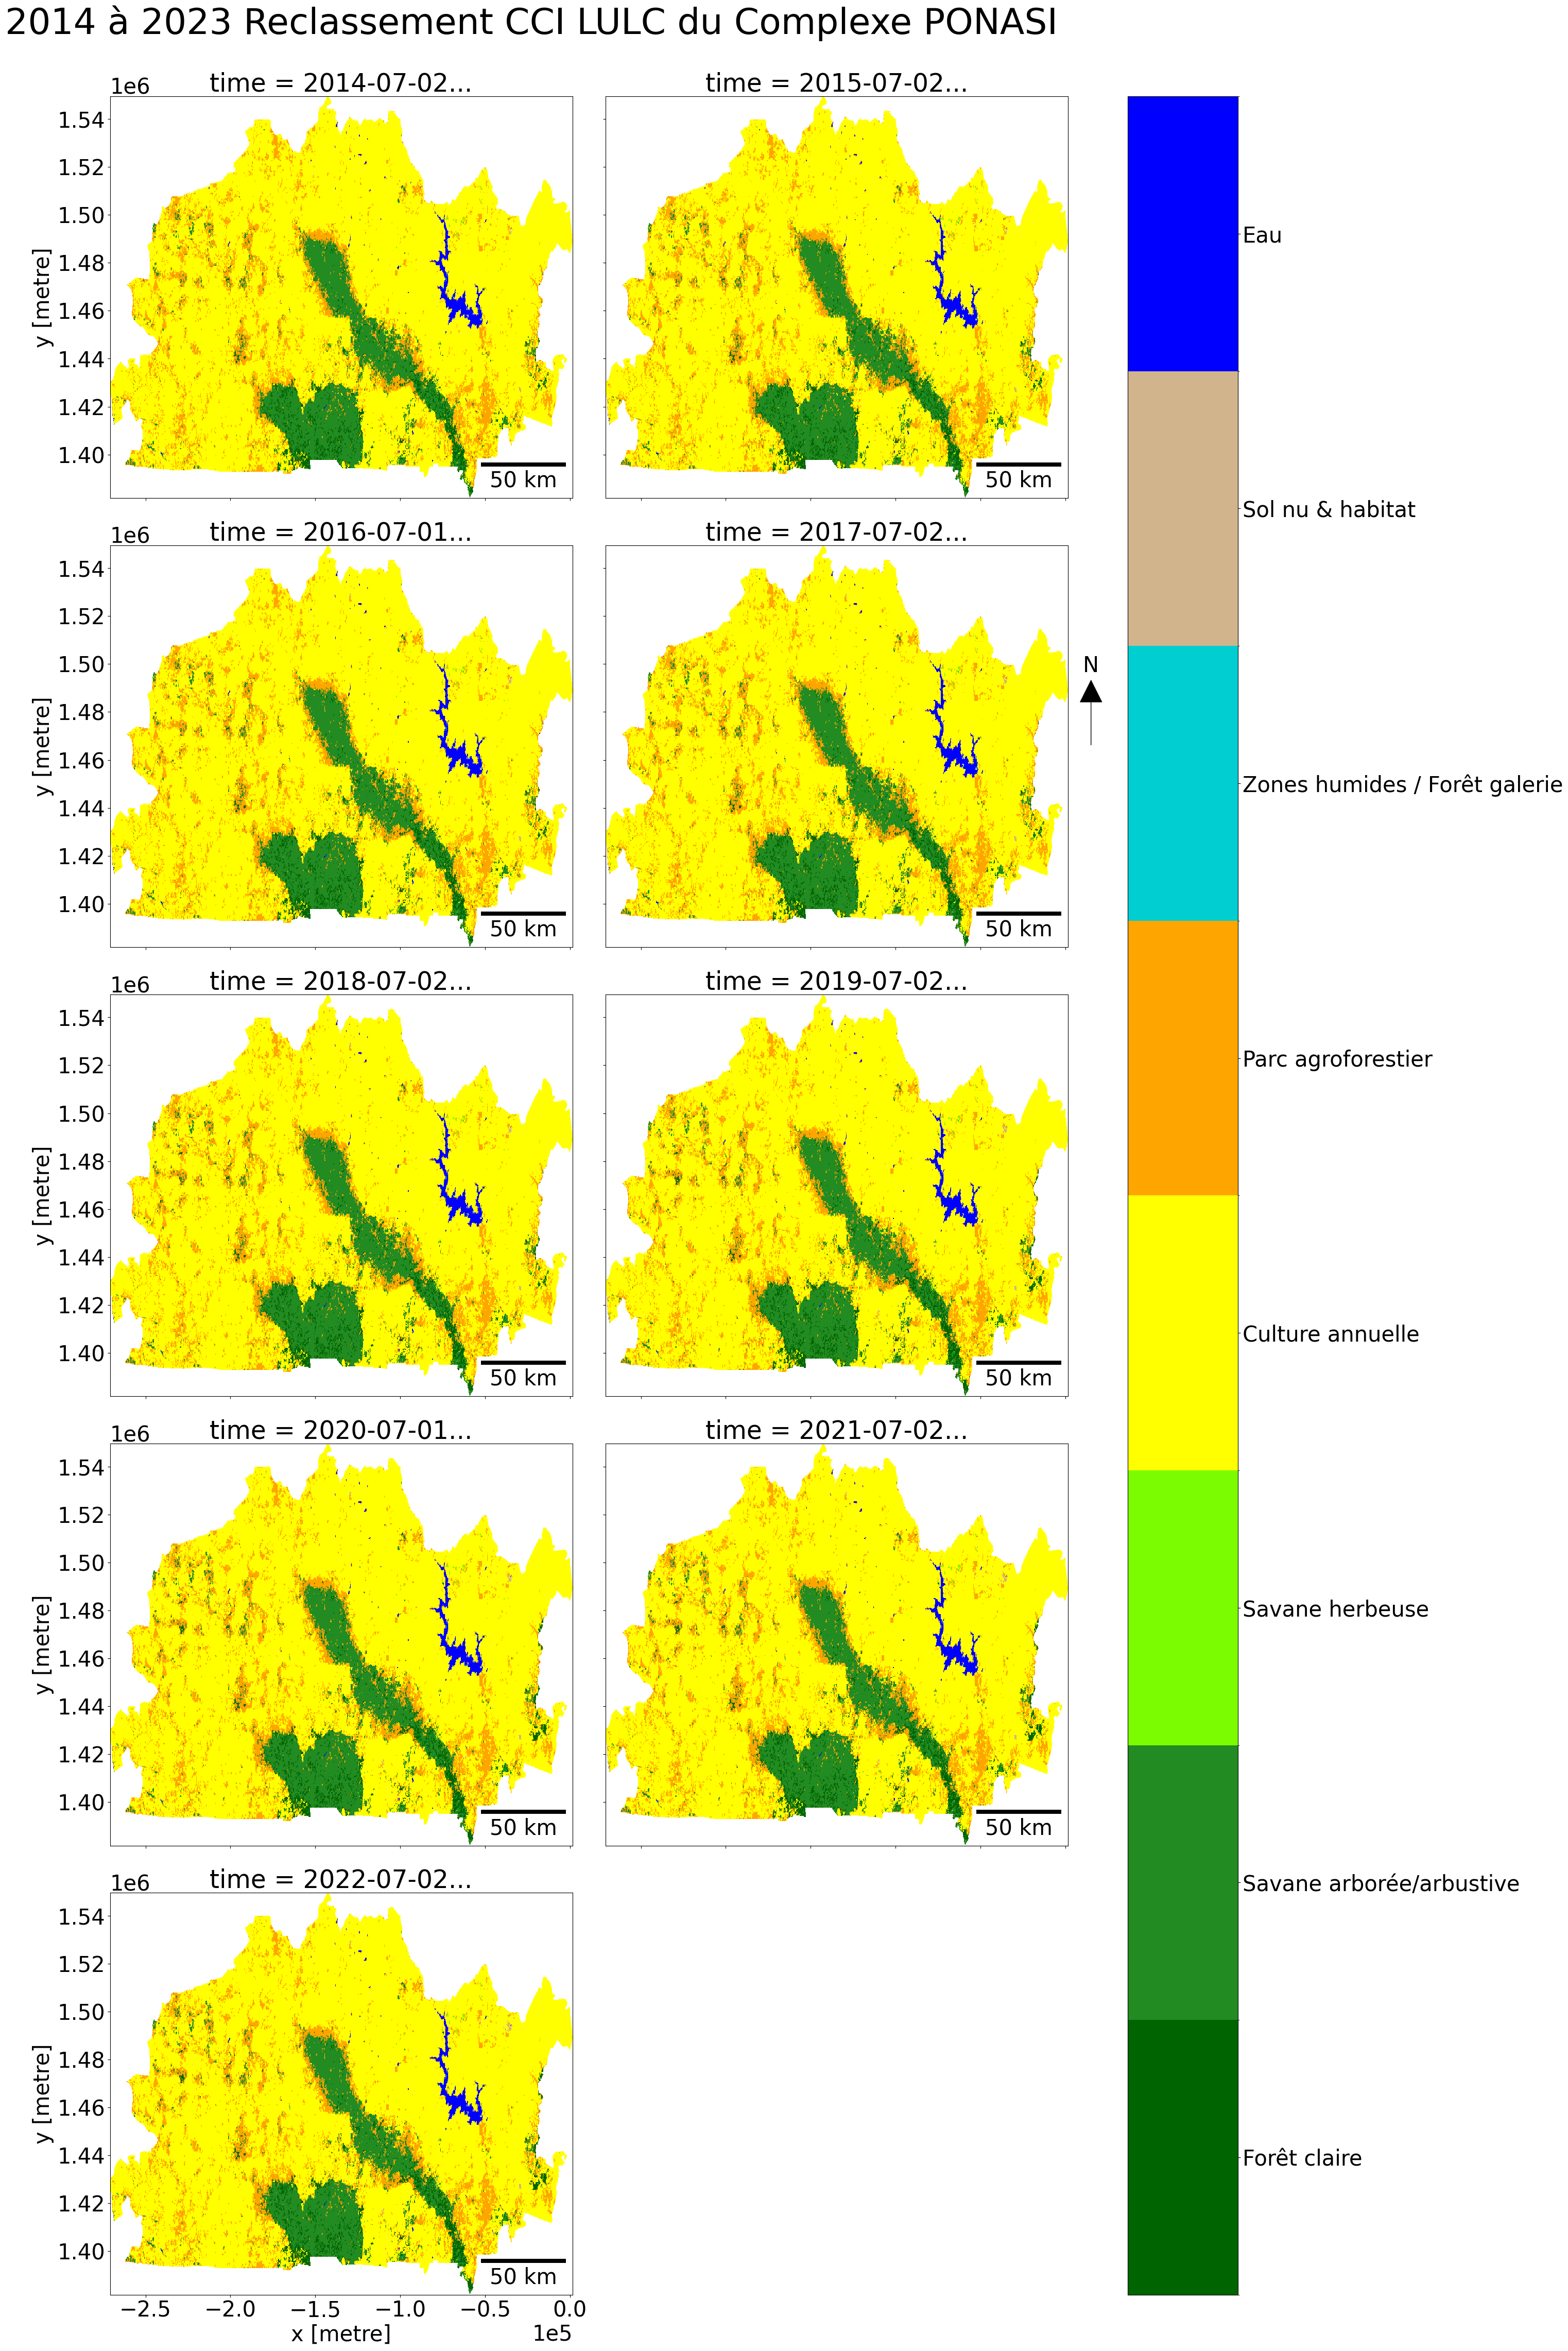

In [16]:
#Visualiser les données reclassées LULC pour chaque pas de temps avec des paramètres personnalisés
#______________________________________________________________

plt.rcParams.update({'font.size': 30})

 

cmap = mcolors.ListedColormap(colors=lulc_colors, N=len(lulc_classes))

bounds = np.arange(min(lulc_classes) - 0.5, max(lulc_classes) + 1, 1)

norm = mcolors.BoundaryNorm(bounds, cmap.N)

 

ncols = 2

 

no_of_subplots = len(ds_lulc.time.values)

 

figure_width = 13 * ncols

figure_length = 10 * (no_of_subplots/ncols)

 

fig = ds_lulc_df.plot(col="time", col_wrap=ncols, add_colorbar=False, figsize=(figure_width,figure_length), cmap=cmap, norm=norm)

 

fig.fig.suptitle(f"{time_range[0]} à {time_range[1]} Reclassement CCI LULC du {country}", x=0.4, y=1.02, size=50)

 

fig.set_titles(template='{coord} = {value}', size=35, maxchar=20)

 

for i, ax in enumerate(fig.axs.flat):

 

    ax.ticklabel_format(axis="both", style='scientific', scilimits=(0, 0))

 

    ax.add_artist(ScaleBar(dx=1, location="lower right"))

 

    if i == 3:

        # Ajouter une flèche du nord au dernier sous-graphe de la figure.

        x, y, arrow_length = 1.05, 0.5, 0.2

        ax.annotate('N', xy=(x, y), xytext=(x, y+arrow_length),

                    arrowprops=dict(arrowstyle='<|-, head_length=1, head_width=0.5', facecolor='black'),

                    ha='center', va='center', fontsize=30,

                    xycoords=ax.transAxes)

 

cbar = plt.colorbar(fig._mappables[-1], ax=fig.axs, ticks=lulc_classes)

cbar.set_ticklabels(lulc_labels)

ax.tick_params(labelsize=32)

 

plt.savefig(f"{output_dir}/{time_range[0]}_to_{time_range[-1]}_{country.replace(' ', '')}_lulc_reclassification.png")

plt.show()

#______________________________________________________________

#Figure 2.3.5 – Carbone interpolé selon la grille LULC

In [17]:
#Définir les étiquettes, classes, couleurs pour la classification des changements : Degradation (Dégradation), Stable (Stable), Improvement (Amélioration)
#______________________________________________________________
#change_labels = ["Degradation", "Stable", "Improvement"]

#change_classes = [-1, 0, 1]

#change_colors = [ "red", "orange", "green"]

#change_class_dict = dict(zip(change_labels, change_classes))

 

#t0 = ds_lulc_df.sel(time=initial_year).squeeze().values


#tn = ds_lulc_df.sel(time=target_year).squeeze().values

import pandas as pd
import numpy as np
import matplotlib.colors as mcolors
# _____________________________________________
# 1. Sélection des années

initial_year = 2014
target_year = 2023

t0 = ds_lulc_df.sel(time=pd.to_datetime(str(initial_year)), method="nearest").squeeze()
tn = ds_lulc_df.sel(time=pd.to_datetime(str(target_year)), method="nearest").squeeze()

# _____________________________________________
# _____________________________________________
# Définition des classes de changement (pour affichage)

change_class_dict = {
    "Stable": 0,
    "Degradation": 1,
    "Improvement": 2
}

change_classes = [0, 1, 2]

change_labels = ["Stable", "Dégradation", "Amélioration"]

change_colors = [
    "#d3d3d3",  # Stable (gris)
    "#d73027",  # Dégradation (rouge)
    "#1a9850"   # Amélioration (vert)
]


In [18]:
#Créer un tableau de changement et classifier les transitions entre les états d’occupation du sol comme Degradation, Stable, or Improvement.
#______________________________________________________________

change = np.full(shape=t0.shape, fill_value=change_class_dict["Stable"])

change = np.where((((t0 == 1) & (tn == 2)) |

                   ((t0 == 1) & (tn == 3)) |

                   ((t0 == 1) & (tn == 4)) |

                   ((t0 == 1) & (tn == 5)) |

                   ((t0 == 1) & (tn == 6)) |

                   ((t0 == 2) & (tn == 3)) |

                   ((t0 == 2) & (tn == 5)) |

                   ((t0 == 2) & (tn == 6)) |

                   ((t0 == 3) & (tn == 5)) |

                   ((t0 == 3) & (tn == 6)) |

                   ((t0 == 4) & (tn == 3)) |

                   ((t0 == 4) & (tn == 5)) |

                   ((t0 == 4) & (tn == 6)) |

                   ((t0 == 6) & (tn == 5))

                  ), change_class_dict["Degradation"], change)





change = np.where((((t0 == 2) & (tn == 1)) |

                   ((t0 == 3) & (tn == 1)) |

                   ((t0 == 3) & (tn == 2)) |

                   ((t0 == 3) & (tn == 4)) |

                   ((t0 == 4) & (tn == 1)) |

                   ((t0 == 5) & (tn == 1)) |

                   ((t0 == 5) & (tn == 2)) |

                   ((t0 == 5) & (tn == 3)) |

                   ((t0 == 5) & (tn == 4)) |

                   ((t0 == 5) & (tn == 6)) |

                   ((t0 == 6) & (tn == 1)) |

                   ((t0 == 6) & (tn == 2)) |

                   ((t0 == 6) & (tn == 3)) |

                   ((t0 == 6) & (tn == 4))

                  ), change_class_dict["Improvement"], change)




ds_change = xr.DataArray(data=change,

                         coords={"y": ds_lulc.y, "x": ds_lulc.x},

                         dims=["y", "x"]).astype(ds_cci.dtype).where(mask)

#______________________________________________________________

/opt/venv/lib/python3.12/site-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(


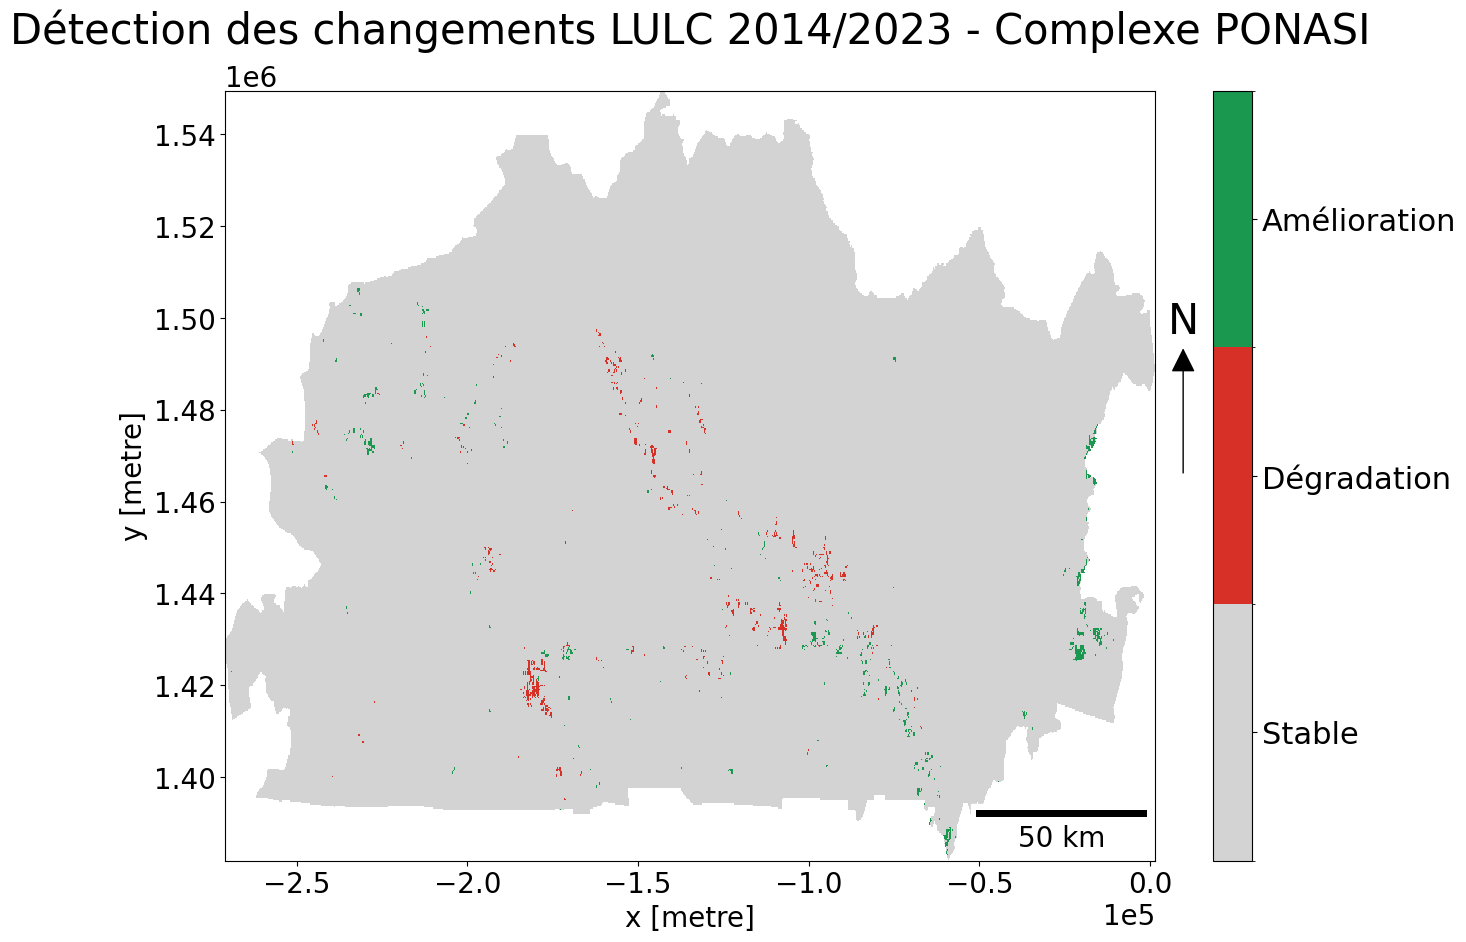

In [19]:


#Plot LULC change detection between two years
#______________________________________________________________

plt.rcParams.update({'font.size': 20})

 

cmap = mcolors.ListedColormap(colors=change_colors, N=len(change_classes))

bounds = np.arange(min(change_classes) - 0.5, max(change_classes) + 1, 1)

norm = mcolors.BoundaryNorm(bounds, cmap.N)

 

fig , ax = plt.subplots(figsize=(15, 10))

im = ds_change.plot.imshow(add_colorbar=False, ax=ax, cmap=cmap, norm=norm)

 

ax.ticklabel_format(axis="both", style='scientific', scilimits=(0, 0))

 

ax.add_artist(ScaleBar(dx=1, location="lower right"))

 

x, y, arrow_length = 1.03, 0.5, 0.2

ax.annotate('N', xy=(x, y), xytext=(x, y+arrow_length),

            arrowprops=dict(arrowstyle='<|-, head_length=0.5, head_width=0.25', facecolor='black'),

            ha='center', va='center', fontsize=30,

            xycoords=ax.transAxes)

 

plt.title(f"Détection des changements LULC {initial_year}/{target_year} - {country}", y=1.05, ha="center", size=30)

 

cbar = plt.colorbar(im, ticks=change_classes)

cbar.set_ticklabels(change_labels)

cbar.ax.tick_params(labelsize=22)

 

plt.show()

#______________________________________________________________

#Figure 2.3.6 – Grille interpolée de carbone 0–30 cm



In [27]:
#______________________________________________________________

def make_pretty(df, title):

    return df.set_caption(title)

#lulc_labels = ["Forest", "Grassland", "Croplands", "Wetlands", "Artificial areas", "Bare lands", "Water bodies"]

lulc_labels = [
    "Forêt claire",
    "Savane arborée/arbustive",
    "Savane herbeuse",
    "Culture annuelle",
    "Parc agroforestier",
    "Zones humides / Forêt galerie",
    "Sol nu & habitat",
    "Eau"
]
 
 #   carbon_stock = {
 #   1: 100,  # Forêt
 #   2: 60,   # Savane arborée
 #   3: 30,   # Savane herbeuse
 #   4: 20,   # Culture annuelle
 #   5: 50,   # Parc agroforestier
 #   6: 80,   # Zone humide
 #   7: 5,    # Sol nu
 #   8: 0     # Eau
 #    }
row_labels = lulc_labels

column_labels = lulc_labels

 

ref_carbon_conversion_matrix = pd.DataFrame(None, index=row_labels, columns=column_labels, dtype=object)

 

ref_carbon_conversion_matrix.index.name = "Year of follow up <br> Initial Year"

 

transitions = {

    ("Forêt claire", "Forêt claire"): ("Stable", 1),

    ("Forêt claire", "Savane arborée/arbustive"): ("Stable", 1),

    ("Forêt claire", "Savane herbeuse"): ("Stable", 1),

    ("Forêt claire", "Culture annuelle"): ("Declining", "f"),

    ("Forêt claire", "Zones humides / Forêt galerie"): ("Stable", 1),

    ("Forêt claire", "Parc agroforestier"): ("Declining", 0.1),

    ("Forêt claire", "Sol nu & habitat"): ("Declining", 0.1),

    ("Forêt claire", "Eau"): ("Stable", 1),


    
    ("Savane arborée/arbustive", "Forêt claire"): ("Stable", 1),

    ("Savane arborée/arbustive", "Savane arborée/arbustive"): ("Stable", 1),

    ("Savane arborée/arbustive", "Savane herbeuse"): ("Stable", 1),

    ("Savane arborée/arbustive", "Culture annuelle"): ("Declining", "f"),

    ("Savane arborée/arbustive", "Zones humides / Forêt galerie"): ("Stable", 1),

    ("Savane arborée/arbustive", "Parc agroforestier"): ("Declining", 0.1),

    ("Savane arborée/arbustive", "Sol nu & habitat"): ("Declining", 0.1),

    ("Savane arborée/arbustive", "Eau"): ("Stable", 1),

    

     ("Parc agroforestier", "Forêt claire"): ("Stable", 1),

    ("Parc agroforestier", "Savane arborée/arbustive"): ("Stable", 1),

    ("Parc agroforestier", "Savane herbeuse"): ("Stable", 1),

    ("Parc agroforestier", "Culture annuelle"): ("Declining", "f"),

    ("Parc agroforestier", "Zones humides / Forêt galerie"): ("Stable", 1),

    ("Parc agroforestier", "Parc agroforestier"): ("Stable", 1),

    ("Parc agroforestier", "Sol nu & habitat"): ("Declining", 0.1),

    ("Parc agroforestier", "Eau"): ("Stable", 1),
 

    ("Savane herbeuse", "Forêt claire"): ("Stable", 1),

    ("Savane herbeuse", "Savane arborée/arbustive"): ("Stable", 1),

    ("Savane herbeuse", "Savane herbeuse"): ("Stable", 1),

    ("Savane herbeuse", "Culture annuelle"): ("Declining", "f"),

    ("Savane herbeuse", "Zones humides / Forêt galerie"): ("Stable", 1),

    ("Savane herbeuse", "Parc agroforestier"): ("Declining", 0.1),

    ("Savane herbeuse", "Sol nu & habitat"): ("Declining", 0.1),

    ("Savane herbeuse", "Eau"): ("Stable", 1),

 

    ("Culture annuelle", "Forêt claire"): ("Improving", "1/f"),

    ("Culture annuelle", "Savane arborée/arbustive"): ("Improving", "1/f"),

    ("Culture annuelle", "Savane herbeuse"): ("Improving", "1/f"),

    ("Culture annuelle", "Culture annuelle"): ("Stable", 1),

    ("Culture annuelle", "Zones humides / Forêt galerie"): ("Improving", "1/0.71"),

    ("Culture annuelle", "Parc agroforestier"): ("Declining", 0.1),

    ("Culture annuelle", "Sol nu & habitat"): ("Declining", 0.1),

    ("Culture annuelle", "Eau"): ("Stable", 1),

 

    ("Zones humides / Forêt galerie", "Forêt claire"): ("Stable", 1),

    ("Zones humides / Forêt galerie", "Savane arborée/arbustive"): ("Stable", 1),

    ("Zones humides / Forêt galerie", "Savane herbeuse"): ("Stable", 1),

    ("Zones humides / Forêt galerie", "Culture annuelle"): ("Declining", 0.71),

    ("Zones humides / Forêt galerie", "Zones humides / Forêt galerie"): ("Stable", 1),

    ("Zones humides / Forêt galerie", "Parc agroforestier"): ("Declining", 0.1),

    ("Zones humides / Forêt galerie", "Sol nu & habitat"): ("Declining", 0.1),

    ("Zones humides / Forêt galerie", "Eau"): ("Stable", 1),

 

   

    ("Sol nu & habitat", "Forêt claire"): ("Improving", 2),

    ("Sol nu & habitat", "Savane arborée/arbustive"): ("Improving", 2),

    ("Sol nu & habitat", "Savane herbeuse"): ("Improving", 2),

    ("Sol nu & habitat", "Culture annuelle"): ("Improving", 2),

    ("Sol nu & habitat", "Zones humides / Forêt galerie"): ("Improving", 2),

    ("Sol nu & habitat", "Parc agroforestier"): ("Stable", 1),

    ("Sol nu & habitat", "Sol nu & habitat"): ("Stable", 1),

    ("Sol nu & habitat", "Eau"): ("Stable", 1),

 

    ("Eau", "Forêt claire"): ("Stable", 1),

    ("Eau", "Savane arborée/arbustive"): ("Stable", 1),

    ("Eau", "Savane herbeuse"): ("Stable", 1),

    ("Eau", "Culture annuelle"): ("Stable", 1),

    ("Eau", "Zones humides / Forêt galerie"): ("Stable", 1),

    ("Eau", "Parc agroforestier"): ("Stable", 1),

    ("Eau", "Sol nu & habitat"): ("Stable", 1),

    ("Eau", "Eau"): ("Stable", 1),

}

 

for (src, dst), (label, value) in transitions.items():

    ref_carbon_conversion_matrix.loc[src, dst] = label

 

ref_carbon_conversion_matrix.reset_index(inplace=True)

 

def lulc_set_background_color(df):

    styles = pd.DataFrame('', index=df.index, columns=df.columns)  # DataFrame vide pour les styles

 

    for index in df.index:

        for col in df.columns[1:]:  # Ignorer la colonne d’index

            value = df.loc[index, col]

            if value == "Stable":

                styles.loc[index, col] = "background-color: orange;"

            elif value == "Declining":

                styles.loc[index, col] = "background-color: red;"

            elif value == "Improving":

                styles.loc[index, col] = "background-color: green;"

 

    return styles




ref_carbon_conversion_matrix = (

    ref_carbon_conversion_matrix

    .style

    .hide(axis="index")

    .apply(lulc_set_background_color, axis=None)

    .pipe(make_pretty, title="Matrice des changements de conversion du carbone")

)




output_dir = './results'

country = "Complexe PONASI"

ref_carbon_conversion_matrix.data.to_csv(f"{output_dir}/{country.replace(' ', '')}_reference_carbon_conversion_matrix.csv", index=False)




display(ref_carbon_conversion_matrix)

#______________________________________________________________

 #Figure 2.3.7 – Statistiques récapitulatives du stock de carbone du sol

Year of follow up Initial Year,Forêt claire,Savane arborée/arbustive,Savane herbeuse,Culture annuelle,Parc agroforestier,Zones humides / Forêt galerie,Sol nu & habitat,Eau,Zone humide
Forêt claire,Stable,Stable,Stable,Declining,Declining,Stable,Declining,Stable,nan
Savane arborée/arbustive,Stable,Stable,Stable,Declining,Declining,Stable,Declining,Stable,nan
Savane herbeuse,Stable,Stable,Stable,Declining,Declining,Stable,Declining,Stable,nan
Culture annuelle,Improving,Improving,Improving,Stable,Declining,Improving,Declining,Stable,nan
Parc agroforestier,Stable,Stable,Stable,Declining,Stable,Stable,Declining,Stable,nan
Zones humides / Forêt galerie,Stable,Stable,Stable,Declining,Declining,Stable,Declining,Stable,nan
Sol nu & habitat,Improving,Improving,Improving,Improving,Stable,nan,Stable,Stable,Improving
Eau,Stable,Stable,Stable,Stable,Stable,Stable,Stable,Stable,nan
